<h1 style="text-align: center;">
Classifying Tennis Match Outcomes from Match Statistics
</h1>

<p align="center">
  <img src="images/tennis_1.jpeg" width="420">
</p>

This project examines how serving performance is associated with winning in men's professional tennis, using ATP match statistics from 2014–2016.

The task is retrospective classification: the models use statistics recorded during a completed match to classify a player's outcome as a win or loss. These results do not measure the ability to predict a match before it begins.

Each observation represents one player's performance in one match, with `outcome = 1` for a win and `outcome = 0` for a loss.

The project has three objectives:

- Compare Logistic Regression, Random Forest, and Gradient Boosting using matches held out from training.
- Identify which serving statistics the models rely on most.
- Examine correct and incorrect classifications through named match examples, distinguishing statistical patterns from explanations the available data cannot establish.

The workflow includes data preparation, feature engineering, model training, Random Forest hyperparameter tuning, evaluation, and interpretation.

To support the full analytical workflow (from data preparation to model development, tuning, and evaluation) we begin by importing the core Python libraries required for data manipulation, model training, and performance assessment. The libraries below enable several key capabilities.

In [1]:
# Efficient data handling, cleaning, feature engineering and visualization
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scales features to mean 0, std 1
from sklearn.preprocessing import StandardScaler

# Chains preprocessing and model steps
from sklearn.pipeline import Pipeline

# The models themselves
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Creation of unbiased training and testing datasets and systematic hyperparameter tuning to improve model performance
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV
)

# The metrics themselves for model comparison
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Dataset and Storage

The project uses ATP match data from the 2014–2016 seasons, stored in three CSV files within the project's `data/` directory:

- `atp_matches_2014.csv`
- `atp_matches_2015.csv`
- `atp_matches_2016.csv`

Each row represents one match and includes the winner, loser, tournament information, score, and serving statistics for both players.

The statistics are match-level totals. They describe measures such as service points played, first-serve points won, and break points faced, but do not record individual serve placement or point-by-point sequences.

The yearly files are combined into a single dataset for preprocessing and analysis.

**Data attribution:** ATP match data by Jeff Sackmann / Tennis Abstract,
downloaded from the [Kadantte/tennis_atp repository](https://github.com/Kadantte/tennis_atp).

The dataset is licensed under
[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International
(CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/).

This notebook filters invalid or incomplete statistical records,
reshapes matches into player observations, and calculates serving rates.
These transformations are documented below.

### Loading and Combining the Raw Match Data

The first step in the analytical workflow is to load the raw ATP match files that form the foundation of the predictive modeling process. The dataset consists of multiple yearly CSV files, each containing detailed match‑level statistics such as serve performance, break‑point outcomes, and match results. To ensure a consistent and scalable data ingestion process, the function below automates the loading and concatenation of all selected years into a single unified dataframe.

This approach provides several benefits:
- It keeps the data pipeline modular and easy to extend if additional years are added.
- It ensures consistent structure across all loaded files.
- It produces a single, consolidated dataset that can be used for cleaning, feature engineering, and model training.

The resulting dataframe serves as the starting point for all subsequent analysis.

In [2]:
def load_data(years=[2014, 2015, 2016], folder_path="data"):
    dfs = []
    for year in years:
        file_path = f"{folder_path}/atp_matches_{year}.csv"
        df_year = pd.read_csv(file_path)
        dfs.append(df_year)
    return pd.concat(dfs, ignore_index=True)

### Transforming Match-Level Data into Player-Match Observations

The raw dataset stores both players' statistics in one row, using separate winner and loser columns, such as `w_ace` and `l_ace`.

For classification, each match is reshaped into two player-match observations:

- The winner's statistics, labeled `outcome = 1`.
- The loser's statistics, labeled `outcome = 0`.

Both observations use the same feature names, such as `ace`, `firstWon`, and `secondWon`, so the models receive a consistent representation of each player's performance.

The two observations from a match are related, not independent. Creating two rows increases the number of player observations but does not increase the number of distinct matches.

A shared `match_id` will identify both observations. Training/test splitting and cross-validation will use this identifier to keep both players from each match in the same partition.

Player names, opponent names, and match identifiers are retained for grouping and interpretation but excluded from the model inputs. The `outcome` column is used only as the target.

In [3]:
def reshape_to_player_match(df):
    df = df.copy()

    # Identify each match using its tournament ID and match number
    df["match_id"] = (
        df["tourney_id"].astype(str)
        + "_"
        + df["match_num"].astype(str)
    )

    if df["match_id"].duplicated().any():
        raise ValueError("Duplicate match IDs found. Check the raw match data.")

    winners = df[[
        "match_id", "winner_name", "loser_name",
        "w_ace", "w_df", "w_svpt", "w_1stIn", "w_1stWon", "w_2ndWon",
        "w_bpSaved", "w_bpFaced"
    ]].copy()

    winners.columns = [
        "match_id", "player", "opponent",
        "ace", "df", "svpt", "firstIn", "firstWon", "secondWon",
        "bpSaved", "bpFaced"
    ]
    winners["outcome"] = 1

    losers = df[[
        "match_id", "loser_name", "winner_name",
        "l_ace", "l_df", "l_svpt", "l_1stIn", "l_1stWon", "l_2ndWon",
        "l_bpSaved", "l_bpFaced"
    ]].copy()

    losers.columns = [
        "match_id", "player", "opponent",
        "ace", "df", "svpt", "firstIn", "firstWon", "secondWon",
        "bpSaved", "bpFaced"
    ]
    losers["outcome"] = 0

    return pd.concat([winners, losers], ignore_index=True)

### Feature Engineering: Measuring Serve Performance

We calculate five rates from each player's match statistics:

- **First-serve percentage:** first serves in ÷ service points played.
- **First-serve points won percentage:** first-serve points won ÷ first serves in.
- **Second-serve points won percentage:** second-serve points won ÷ service points where the first serve missed.
- **Total serve points won percentage:** first- and second-serve points won combined ÷ service points played.
- **Break-point save percentage:** break points saved ÷ break points faced.

These features measure different aspects of serving performance. Landing a first serve in play is different from winning the resulting point.

Rates are stored as proportions between 0 and 1. Compared with raw counts, they make performance easier to compare across matches of different lengths.

Zero denominators require explicit handling. A player who faced no break points has an undefined break-point save rate, rather than a demonstrated 0% success rate. We therefore include a separate indicator identifying players who faced no break points.

These statistics summarize match performance but do not directly measure serve placement, speed, or spin.

In [4]:
def add_features(df):
    df = df.copy()

    # Replace zero denominators with NaN before division
    service_points = df["svpt"].replace(0, np.nan)
    first_serves_in = df["firstIn"].replace(0, np.nan)
    second_serve_points = (
        df["svpt"] - df["firstIn"]
    ).replace(0, np.nan)
    break_points_faced = df["bpFaced"].replace(0, np.nan)

    df["first_serve_pct"] = (
        df["firstIn"] / service_points
    )

    df["first_serve_points_won_pct"] = (
        df["firstWon"] / first_serves_in
    )

    df["second_serve_points_won_pct"] = (
        df["secondWon"] / second_serve_points
    )

    df["total_serve_points_won_pct"] = (
        (df["firstWon"] + df["secondWon"]) / service_points
    )

    df["bp_save_pct"] = (
        df["bpSaved"] / break_points_faced
    )

    # Distinguish no break points faced from unsuccessful saves
    no_break_points = df["bpFaced"].eq(0)
    df["no_break_points_faced"] = no_break_points.astype(int)

    # Numeric placeholder; the indicator preserves its meaning
    df.loc[no_break_points, "bp_save_pct"] = 0.0

    return df

### Preparing Complete and Valid Match Records

The preprocessing function combines reshaping, feature engineering, and data-quality checks.

It retains matches only when both players have complete, valid inputs. Checks cover:

- Missing or non-finite numeric values.
- Negative counts or points won exceeding the available opportunities.
- Engineered rates outside the range from 0 to 1.

Undefined serving rates remain missing and lead to exclusion. For players who faced no break points, the break-point save rate uses the numeric placeholder and separate indicator described above.

If either player's record fails these checks, both observations from that match are removed. This preserves the paired match structure and equal numbers of winning and losing observations.

The shared `match_id` is retained for grouped splitting and cross-validation.

In [5]:
def preprocess_for_outcome(df):
    df = add_features(reshape_to_player_match(df))

    count_columns = [
        "ace", "df", "svpt", "firstIn", "firstWon",
        "secondWon", "bpSaved", "bpFaced"
    ]

    rate_columns = [
        "first_serve_pct",
        "first_serve_points_won_pct",
        "second_serve_points_won_pct",
        "total_serve_points_won_pct",
        "bp_save_pct"
    ]

    # Check for missing values, infinity, and negative counts
    complete = df.notna().all(axis=1)
    finite = np.isfinite(
        df[count_columns + rate_columns]
    ).all(axis=1)
    nonnegative = df[count_columns].ge(0).all(axis=1)

    # All calculated rates must fall between 0 and 1
    valid_rates = (
        df[rate_columns].ge(0).all(axis=1)
        & df[rate_columns].le(1).all(axis=1)
    )

    # Check that recorded counts are internally consistent
    valid_counts = (
        (df["svpt"] > 0)
        & (df["firstIn"] <= df["svpt"])
        & (df["firstWon"] <= df["firstIn"])
        & (
            df["secondWon"] + df["df"]
            <= df["svpt"] - df["firstIn"]
        )
        & (df["ace"] <= df["firstWon"] + df["secondWon"])
        & (df["bpSaved"] <= df["bpFaced"])
    )

    valid_rows = (
        complete & finite & nonnegative & valid_rates & valid_counts
    )

    # Exclude the entire match if either player's record is invalid
    invalid_match_ids = df.loc[~valid_rows, "match_id"]

    return df.loc[
        ~df["match_id"].isin(invalid_match_ids)
    ].copy()

### Splitting the Data by Match

We allocate approximately 80% of matches to training and 20% to testing using `GroupShuffleSplit`.

The shared `match_id` keeps both players from each match in the same subset. This ensures that matches represented in the test set are absent from training.

Because every retained match contains one winning and one losing observation, both subsets remain balanced between the two outcomes. A fixed `random_state = 42` makes the split reproducible.

Player names, opponent names, and match identifiers are excluded from the model inputs. The `outcome` column provides the target labels.

Hyperparameter tuning will use grouped cross-validation within the training set, preserving the same separation by match.

In [6]:
def train_test(df):
    X = df.drop(
        columns=["match_id", "player", "opponent", "outcome"]
    )
    y = df["outcome"]
    groups = df["match_id"]

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(
        splitter.split(X, y, groups=groups)
    )

    # Verify that no match appears in both subsets
    train_matches = set(groups.iloc[train_idx])
    test_matches = set(groups.iloc[test_idx])

    assert train_matches.isdisjoint(test_matches), (
        "A match appears in both training and test data."
    )

    return (
        X.iloc[train_idx].copy(),
        X.iloc[test_idx].copy(),
        y.iloc[train_idx].copy(),
        y.iloc[test_idx].copy()
    )

### Training a Random Forest Baseline

Random Forest combines multiple decision trees by averaging their predicted class probabilities. It can capture nonlinear relationships and interactions between serving statistics.

The initial configuration uses:

- `n_estimators = 500`: builds 500 trees.
- `max_depth = 8`: limits the depth of each tree.
- `min_samples_leaf = 20`: requires at least 20 training observations in each leaf.
- `max_features = "sqrt"`: considers a random subset of features at each split.
- `random_state = 42`: makes training reproducible.

The depth and leaf-size restrictions constrain model complexity. Their effectiveness will be assessed through evaluation on held-out matches.

This model provides an initial Random Forest benchmark. A later grid search will compare alternative configurations using grouped cross-validation within the training set.

In [7]:
def train_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=20,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model

### Training a Logistic Regression Baseline

Logistic Regression provides a linear baseline for comparison with Random Forest and Gradient Boosting. It models the log-odds of winning as a linear combination of the input features.

The model is trained inside a pipeline that:

1. Standardizes features using `StandardScaler`, fitted only on the training data.
2. Fits Logistic Regression with `max_iter = 2000` to allow sufficient optimization iterations.

Standardization puts features measured on different scales, such as service-point counts and serving percentages, on a comparable basis.

The coefficients describe how each standardized feature contributes to the model's prediction, conditional on the other inputs. However, several features are closely related—for example, service-point counts and the percentages derived from them. Their coefficients should therefore be interpreted together, rather than treated as independent measures of a statistic's importance.

Coefficient signs describe associations learned by the model; they do not establish that changing a statistic would cause a player to win or lose.

In [8]:
def train_model_2(X_train, y_train):
    model_2 = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            max_iter=2000,
            solver='lbfgs'
        ))
    ])
    model_2.fit(X_train, y_train)
    return model_2

### Training a Gradient Boosting Classifier

Gradient Boosting builds decision trees sequentially, with each new tree helping reduce the model's remaining training loss. This approach can capture nonlinear relationships and interactions between serving statistics.

The configuration uses:

- `learning_rate = 0.05`: controls how much each new tree contributes.
- `n_estimators = 300`: builds 300 trees in sequence.
- `max_depth = 3`: limits the depth of each tree.
- `random_state = 42`: makes training reproducible.

The learning rate, number of trees, and tree depth jointly control the model's flexibility. Their values do not guarantee that overfitting is avoided.

Gradient Boosting is evaluated on the same held-out matches as the other models. We compare their classification metrics and interpret small performance differences cautiously.

In [10]:
def train_model_3(X_train, y_train):
    model_3 = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        max_depth=3,
        random_state=42
    )

    model_3.fit(X_train, y_train)
    return model_3

### Evaluating Classification Performance

Each model is evaluated on the same held-out matches using three outputs:

- **Accuracy:** the proportion of player-match observations classified correctly.
- **Classification report:** precision, recall, and F1-score for losses (`0`) and wins (`1`).
- **Confusion matrix:** counts of correct and incorrect classifications, with rows representing actual outcomes and columns representing predicted outcomes.

These metrics are calculated per player-match observation. Each held-out match contributes two observations: one for the winner and one for the loser.

Because the test set contains equal numbers of wins and losses, predicting the same class for every observation would achieve 50% accuracy. This provides a simple reference for interpreting model performance.

The evaluation function also returns the calculated metrics so that later comparison tables can use the actual results without manually entered scores.

In [11]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)

    report = classification_report(
        y_test,
        preds,
        labels=[0, 1],
        target_names=["Loss", "Win"],
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_test, preds, labels=[0, 1])

    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification report:")
    print(classification_report(
        y_test,
        preds,
        labels=[0, 1],
        target_names=["Loss", "Win"],
        digits=3,
        zero_division=0
    ))

    print("Confusion matrix:")
    print("Rows = actual; columns = predicted")
    print("Class order: Loss (0), Win (1)")
    print(cm)

    return {
        "Accuracy": accuracy,
        "Macro F1": report["macro avg"]["f1-score"]
    }

### Inspecting the Prepared Dataset and Data Split

We now load the yearly files, apply preprocessing, and split the retained matches into training and test sets.

The output summarizes:

- The number of raw, retained, and excluded matches.
- The number of player-match observations and model features.
- Training and test set sizes and class distributions.
- The number of match identifiers shared between training and testing, which must be zero.

Each retained match should contribute exactly two observations: one win and one loss. Player names, opponent names, and match identifiers remain available in the prepared dataset but are excluded from the model inputs.

A preview of the prepared data allows us to inspect the resulting columns and values. All reported counts are calculated from the current run.

In [12]:
# Load, preprocess, and split the data
df_raw = load_data([2014, 2015, 2016], "data")
df = preprocess_for_outcome(df_raw)

X_train, X_test, y_train, y_test = train_test(df)

# Identify the matches in each subset
train_matches = set(df.loc[X_train.index, "match_id"])
test_matches = set(df.loc[X_test.index, "match_id"])
shared_matches = train_matches & test_matches

# Verify that each retained match has one winner and one loser
match_summary = df.groupby("match_id")["outcome"].agg(["size", "sum"])

assert match_summary["size"].eq(2).all(), (
    "Some matches do not contain exactly two observations."
)
assert match_summary["sum"].eq(1).all(), (
    "Some matches do not contain one winner and one loser."
)
assert not shared_matches, "Training and test matches overlap."

# Summarize the prepared dataset
retained_matches = df["match_id"].nunique()

print(f"Raw matches: {len(df_raw):,}")
print(f"Retained matches: {retained_matches:,}")
print(f"Excluded matches: {len(df_raw) - retained_matches:,}")
print(f"Player-match observations: {len(df):,}")
print(f"Prepared dataset shape: {df.shape}")
print(f"Model features: {X_train.shape[1]}")

print(
    f"\nTraining: {len(train_matches):,} matches, "
    f"{len(X_train):,} observations"
)
print(
    f"Test: {len(test_matches):,} matches, "
    f"{len(X_test):,} observations"
)
print(f"Shared matches: {len(shared_matches)}")
print("Match-pair checks: passed")

# Display class balance
class_counts = pd.DataFrame({
    "Training": y_train.value_counts().reindex([0, 1], fill_value=0),
    "Test": y_test.value_counts().reindex([0, 1], fill_value=0)
})
class_counts.index = ["Loss (0)", "Win (1)"]

print("\nClass distributions:")
display(class_counts)

print("\nPrepared dataset preview:")
display(df.head())

Raw matches: 8,785
Retained matches: 8,107
Excluded matches: 678
Player-match observations: 16,214
Prepared dataset shape: (16214, 18)
Model features: 14

Training: 6,485 matches, 12,970 observations
Test: 1,622 matches, 3,244 observations
Shared matches: 0
Match-pair checks: passed

Class distributions:


,Training,Test
Loss (0),6485,1622
Win (1),6485,1622



Prepared dataset preview:


,match_id,player,opponent,ace,df,svpt,firstIn,firstWon,secondWon,bpSaved,bpFaced,outcome,first_serve_pct,first_serve_points_won_pct,second_serve_points_won_pct,total_serve_points_won_pct,bp_save_pct,no_break_points_faced
0,2014-339_1,Jarkko Nieminen,James Duckworth,5.0,3.0,71.0,54.0,36.0,9.0,5.0,5.0,1,0.760563,0.666667,0.529412,0.633803,1.000000,0
1,2014-339_2,Marinko Matosevic,Julien Benneteau,11.0,3.0,112.0,68.0,43.0,26.0,5.0,9.0,1,0.607143,0.632353,0.590909,0.616071,0.555556,0
2,2014-339_3,Sam Querrey,Dmitry Tursunov,18.0,1.0,58.0,40.0,36.0,7.0,2.0,3.0,1,0.689655,0.900000,0.388889,0.741379,0.666667,0
3,2014-339_4,Sam Groth,Ryan Harrison,23.0,2.0,70.0,51.0,46.0,10.0,1.0,1.0,1,0.728571,0.901961,0.526316,0.800000,1.000000,0
4,2014-339_5,Nicolas Mahut,Igor Sijsling,15.0,4.0,100.0,59.0,46.0,18.0,4.0,6.0,1,0.590000,0.779661,0.439024,0.640000,0.666667,0


In [13]:
print(df_raw.shape)

df_raw.head()

(8785, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2014-339,Brisbane,Hard,28,A,20131229,1,103813,NaN,NaN,...,29.0,23.0,6.0,8.0,2.0,5.0,39.0,1090.0,136.0,425.0
1,2014-339,Brisbane,Hard,28,A,20131229,2,104594,NaN,NaN,...,76.0,51.0,18.0,17.0,7.0,11.0,61.0,774.0,35.0,1160.0
2,2014-339,Brisbane,Hard,28,A,20131229,3,105023,NaN,NaN,...,40.0,26.0,12.0,11.0,6.0,9.0,46.0,960.0,29.0,1244.0
3,2014-339,Brisbane,Hard,28,A,20131229,4,105032,NaN,WC,...,59.0,43.0,15.0,12.0,4.0,4.0,172.0,307.0,100.0,549.0
4,2014-339,Brisbane,Hard,28,A,20131229,5,103917,NaN,NaN,...,50.0,43.0,12.0,14.0,2.0,4.0,50.0,918.0,70.0,697.0


### Running the First Full Model Pass
This cell executes the first complete modeling loop using the Random Forest classifier, and the model produces a meaningful evaluation on unseen matches.

Put into more detail:
- Trains the regularized Random Forest model.
- Evaluates accuracy, precision, recall, F1‑score, and the confusion matrix.

This gives you the first benchmark for model performance and establishes a reference point for comparing Logistic Regression and Gradient Boosting later.


In [14]:
# Train the Random Forest baseline
model = train_model(X_train, y_train)

# Evaluate and save the metrics for the comparison table
rf_results = evaluate_model(model, X_test, y_test)

Accuracy: 0.7891

Classification report:
              precision    recall  f1-score   support

        Loss      0.801     0.770     0.785      1622
         Win      0.779     0.808     0.793      1622

    accuracy                          0.789      3244
   macro avg      0.790     0.789     0.789      3244
weighted avg      0.790     0.789     0.789      3244

Confusion matrix:
Rows = actual; columns = predicted
Class order: Loss (0), Win (1)
[[1249  373]
 [ 311 1311]]


### Interpreting the Random Forest Baseline

The Random Forest correctly classified 2,560 of 3,244 player-match observations, achieving **78.91% accuracy** and a **macro F1-score of approximately 0.789**.

This exceeds the 50% accuracy of a constant-class prediction on the balanced test set. Evaluation covers 1,622 matches that were excluded entirely from training.

The confusion matrix shows:

- **1,249** actual losses correctly classified as losses.
- **1,311** actual wins correctly classified as wins.
- **373** actual losses incorrectly classified as wins.
- **311** actual wins incorrectly classified as losses.

Recall is slightly higher for wins (**80.8%**) than for losses (**77.0%**). The model therefore identifies a larger proportion of actual winners and makes somewhat more errors by classifying losing players as winners.

These results indicate that serving statistics contain useful information for retrospective outcome classification within this dataset. They establish a baseline for comparison with the tuned Random Forest, Logistic Regression, and Gradient Boosting models.

### Tuning Random Forest with Grouped Cross-Validation

We use `GridSearchCV` to compare Random Forest configurations within the training set.

A three-fold `GroupKFold` split keeps both players from each match together. Each configuration is evaluated on validation matches that are absent from that fold's training data.

The search covers:

- `n_estimators`: 200 and 500.
- `max_depth`: 6, 8, and 12.
- `min_samples_split`: 2, 10, and 20.
- `min_samples_leaf`: 1, 5, and 20.
- `max_features`: `"sqrt"`.

This produces 54 parameter combinations and 162 cross-validation fits. The configuration with the highest mean validation accuracy is then refitted on the complete training set.

The held-out test set is excluded from hyperparameter selection and used afterward to evaluate the selected configuration.

In [15]:
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [6, 8, 12],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt"]
}

# Let GridSearchCV manage parallel processing
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

# Match identifiers aligned with the training observations
train_groups = df.loc[X_train.index, "match_id"]

grouped_cv = GroupKFold(n_splits=3)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=grouped_cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train,
    groups=train_groups
)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 8, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceval

In [16]:
best_rf = grid.best_estimator_
best_params = grid.best_params_

best_cv_std = grid.cv_results_["std_test_score"][grid.best_index_]

print("Selected Random Forest parameters:")
for parameter, value in best_params.items():
    print(f"  {parameter}: {value}")

print(f"\nMean grouped CV accuracy: {grid.best_score_:.4f}")
print(f"CV accuracy standard deviation: {best_cv_std:.4f}")

Selected Random Forest parameters:
  max_depth: 8
  max_features: sqrt
  min_samples_leaf: 5
  min_samples_split: 20
  n_estimators: 500

Mean grouped CV accuracy: 0.7933
CV accuracy standard deviation: 0.0029


### Interpreting the Selected Random Forest Configuration

The grid search compared 54 configurations using three-fold grouped cross-validation and selected:

- `n_estimators = 500`: 500 trees.
- `max_depth = 8`: a maximum depth of eight levels.
- `min_samples_leaf = 5`: at least five training observations per leaf.
- `min_samples_split = 20`: at least 20 training observations before a node can be split.
- `max_features = "sqrt"`: three candidate features per split with our 14 input features.

Compared with the baseline, the selected configuration retains the same number of trees and maximum depth. It allows smaller leaves—five observations instead of 20—while increasing the minimum split threshold from 10 to 20.

Selection was based on mean validation accuracy within the training set. The selected model was then refitted on the complete training set.

The next step evaluates this model on the held-out test matches to determine whether tuning improved performance relative to the baseline.

In [17]:
# Evaluate the tuned Random Forest and save its test metrics
tuned_rf_results = evaluate_model(best_rf, X_test, y_test)

Accuracy: 0.7879

Classification report:
              precision    recall  f1-score   support

        Loss      0.799     0.769     0.784      1622
         Win      0.777     0.807     0.792      1622

    accuracy                          0.788      3244
   macro avg      0.788     0.788     0.788      3244
weighted avg      0.788     0.788     0.788      3244

Confusion matrix:
Rows = actual; columns = predicted
Class order: Loss (0), Win (1)
[[1247  375]
 [ 313 1309]]


### Comparing the Tuned Random Forest with the Baseline

| Configuration | Test accuracy | Macro F1 |
|---|---:|---:|
| Random Forest baseline | 78.91% | 0.789 |
| Tuned Random Forest | 78.79% | 0.788 |

The tuned model correctly classified 2,556 of 3,244 player-match observations, compared with 2,560 for the baseline. This represents four fewer correct classifications, a difference of approximately **0.12 percentage points** in accuracy.

Its error pattern remains similar to the baseline:

- **375** actual losses were classified as wins.
- **313** actual wins were classified as losses.

The configuration selected through grouped cross-validation did not improve test accuracy in this run. Selecting the highest validation score does not guarantee an improvement on a separate test set.

The small difference does not establish that either configuration is generally superior. Both results will be retained in the final comparison.

In [18]:
# Rank the tuned Random Forest's feature importances
importance_series = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns,
    name="Importance"
).sort_values(ascending=False)

importance_series = importance_series.rename_axis("Feature")

display(importance_series.to_frame().round(4))

,Importance
Feature,
total_serve_points_won_pct,0.3484
first_serve_points_won_pct,0.1761
second_serve_points_won_pct,0.1235
bpFaced,0.1047
bp_save_pct,0.0997
firstWon,0.0286
svpt,0.0223
bpSaved,0.0173
firstIn,0.0168


### Understanding Random Forest Feature Importance

The tuned Random Forest reports impurity-based feature importances. These summarize how much each feature contributes to separating wins from losses during tree construction, averaged across the forest.

The scores are normalized to sum to 1 before rounding. Higher scores indicate greater importance within this fitted model, but do not show whether higher feature values favor a win or a loss.

Several inputs are closely related, including total serve points won percentage and its first- and second-serve components. Correlated features can share or substitute for one another's importance, so their rankings should be interpreted together.

Impurity-based importance can also favor features with more possible split points. It describes the model's overall use of its inputs; it does not establish what caused a player to win or explain an individual classification.

The following chart visualizes these scores for the tuned Random Forest.

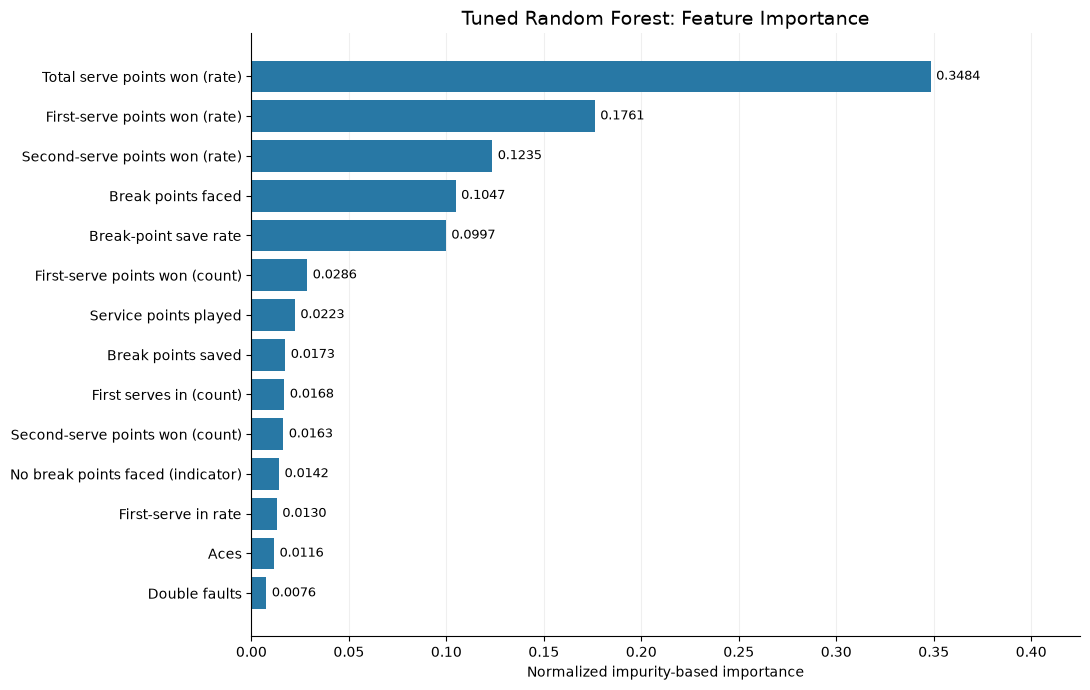

In [19]:
# Readable labels for the chart
feature_labels = {
    "total_serve_points_won_pct": "Total serve points won (rate)",
    "first_serve_points_won_pct": "First-serve points won (rate)",
    "second_serve_points_won_pct": "Second-serve points won (rate)",
    "bpFaced": "Break points faced",
    "bp_save_pct": "Break-point save rate",
    "firstWon": "First-serve points won (count)",
    "svpt": "Service points played",
    "bpSaved": "Break points saved",
    "firstIn": "First serves in (count)",
    "secondWon": "Second-serve points won (count)",
    "no_break_points_faced": "No break points faced (indicator)",
    "first_serve_pct": "First-serve in rate",
    "ace": "Aces",
    "df": "Double faults"
}

# Ascending order places the largest horizontal bar at the top
plot_importances = importance_series.sort_values()
labels = [
    feature_labels.get(feature, feature)
    for feature in plot_importances.index
]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    labels,
    plot_importances.values,
    color="#2878A5"
)

ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)

ax.set_title("Tuned Random Forest: Feature Importance", fontsize=14)
ax.set_xlabel("Normalized impurity-based importance")
ax.set_ylabel("")
ax.set_xlim(0, plot_importances.max() * 1.22)

ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.2)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

### Interpreting the Tuned Random Forest’s Feature Rankings

The three highest-ranked features are:

| Feature | Importance |
|---|---:|
| Total serve points won rate | 0.3484 |
| First-serve points won rate | 0.1761 |
| Second-serve points won rate | 0.1235 |

The model assigns its greatest importance to the proportion of service points won overall. First- and second-serve points won rates provide additional information about performance in each serving situation.

Break points faced (**0.1047**) and break-point save rate (**0.0997**) rank next, indicating that the model also uses information about service games coming under pressure.

First-serve in rate receives considerably less importance (**0.0130**). This distinction matters: landing a first serve in play and winning the resulting point measure different aspects of performance. This model places greater importance on service-point outcomes.

Aces and double faults also receive relatively low importance. This does not establish that they are unimportant in tennis; related features may already capture some of their information.

These rankings describe the fitted model’s overall use of its inputs. They do not establish why a particular player won or which feature drove an individual classification.

### Evaluating the Logistic Regression Baseline

We fit the Logistic Regression pipeline on the training observations and evaluate it on the same held-out matches as both Random Forest configurations.

The pipeline fits its scaler exclusively on the training data and applies that transformation to the test data.

Logistic Regression provides a linear baseline for comparison with the tree-based models. We report accuracy, macro F1, class-specific metrics, and the confusion matrix using the same evaluation function.

In [20]:
# Train the Logistic Regression pipeline
model_2 = train_model_2(X_train, y_train)

# Evaluate and save its test metrics
lr_results = evaluate_model(model_2, X_test, y_test)

Accuracy: 0.7895

Classification report:
              precision    recall  f1-score   support

        Loss      0.791     0.786     0.789      1622
         Win      0.788     0.793     0.790      1622

    accuracy                          0.789      3244
   macro avg      0.789     0.789     0.789      3244
weighted avg      0.789     0.789     0.789      3244

Confusion matrix:
Rows = actual; columns = predicted
Class order: Loss (0), Win (1)
[[1275  347]
 [ 336 1286]]


### Interpreting the Logistic Regression Results

Logistic Regression correctly classified **2,561 of 3,244 player-match observations**, achieving **78.95% accuracy** and a **macro F1-score of approximately 0.789**.

The confusion matrix shows:

- **1,275** actual losses correctly classified as losses.
- **1,286** actual wins correctly classified as wins.
- **347** actual losses incorrectly classified as wins.
- **336** actual wins incorrectly classified as losses.

Recall is similar across classes: **78.6% for losses** and **79.3% for wins**. Its errors are more evenly distributed between the two classes than those of the Random Forest models.

Logistic Regression makes one more correct classification than the Random Forest baseline and five more than the tuned Random Forest. These small differences provide little basis for preferring one model on accuracy alone.

For this feature set and test split, the linear model achieves performance comparable to both Random Forest configurations. This supports retaining Logistic Regression as a competitive baseline.

### Evaluating the Gradient Boosting Model

We train Gradient Boosting using the same features and training observations as the other models, then evaluate it on the same held-out matches.

The model uses the fixed configuration defined earlier: 300 trees, a learning rate of 0.05, a maximum tree depth of 3, and `random_state = 42`.

The shared evaluation function reports accuracy, macro F1, class-specific metrics, and the confusion matrix.

This comparison examines whether Gradient Boosting improves classification performance over Logistic Regression and the Random Forest configurations. Small differences on this single test split will be interpreted cautiously.

In [21]:
# Train the Gradient Boosting classifier
model_3 = train_model_3(X_train, y_train)

# Evaluate and save its test metrics
gb_results = evaluate_model(model_3, X_test, y_test)

Accuracy: 0.7876

Classification report:
              precision    recall  f1-score   support

        Loss      0.793     0.778     0.786      1622
         Win      0.782     0.797     0.790      1622

    accuracy                          0.788      3244
   macro avg      0.788     0.788     0.788      3244
weighted avg      0.788     0.788     0.788      3244

Confusion matrix:
Rows = actual; columns = predicted
Class order: Loss (0), Win (1)
[[1262  360]
 [ 329 1293]]


### Interpreting the Gradient Boosting Results

Gradient Boosting correctly classified **2,555 of 3,244 player-match observations**, achieving **78.76% accuracy** and a **macro F1-score of approximately 0.788**.

The confusion matrix shows:

- **1,262** actual losses correctly classified as losses.
- **1,293** actual wins correctly classified as wins.
- **360** actual losses incorrectly classified as wins.
- **329** actual wins incorrectly classified as losses.

Recall is slightly higher for wins (**79.7%**) than for losses (**77.8%**).

With the current configuration, Gradient Boosting does not improve test accuracy over the other models. It makes five fewer correct classifications than the Random Forest baseline, one fewer than the tuned Random Forest, and six fewer than Logistic Regression.

These differences are small. The results provide no clear performance advantage for Gradient Boosting on this feature set and test split, despite its ability to model nonlinear relationships.

In [22]:
# Build the comparison from the actual evaluation results
comparison_df = pd.DataFrame.from_dict(
    {
        "Random Forest (Baseline)": rf_results,
        "Random Forest (Tuned)": tuned_rf_results,
        "Logistic Regression": lr_results,
        "Gradient Boosting": gb_results
    },
    orient="index"
)

comparison_df = (
    comparison_df
    .rename_axis("Model")
    .sort_values("Accuracy", ascending=False)
)

# Format for display while preserving the underlying precision
display(
    comparison_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.3f}"
    })
)

,Accuracy,Macro F1
Model,,
Logistic Regression,78.95%,0.789
Random Forest (Baseline),78.91%,0.789
Random Forest (Tuned),78.79%,0.788
Gradient Boosting,78.76%,0.788


### What the Model Comparison Shows

All four configurations achieve similar test performance: accuracy ranges from **78.76% to 78.95%**, with macro F1-scores of approximately **0.788–0.789**.

Logistic Regression has the highest observed accuracy, but it makes only one more correct classification than the Random Forest baseline and six more than Gradient Boosting. The full accuracy range is less than 0.2 percentage points.

The tree-based models therefore show no clear performance advantage over Logistic Regression with the current features and configurations. Random Forest tuning also produces no improvement in held-out accuracy.

These results describe one test split. They do not establish a statistically significant ranking or prove that the models will perform equally well on other seasons.

Logistic Regression is a reasonable choice for the detailed match examples because it combines competitive performance with a model structure that allows direct inspection of feature contributions. The other models remain useful comparisons.

### Comparing Confusion Matrices Across All Models

The following figure compares the Random Forest baseline, tuned Random Forest, Logistic Regression, and Gradient Boosting on the same test observations.

Each matrix uses the same arrangement:

- Rows represent actual outcomes.
- Columns represent predicted outcomes.
- Class order is loss (`0`), followed by win (`1`).
- Diagonal entries count correct classifications.
- Off-diagonal entries count classification errors.

A shared color scale makes the counts comparable across panels. The matrices help reveal whether models with similar overall accuracy distribute their errors differently between wins and losses.

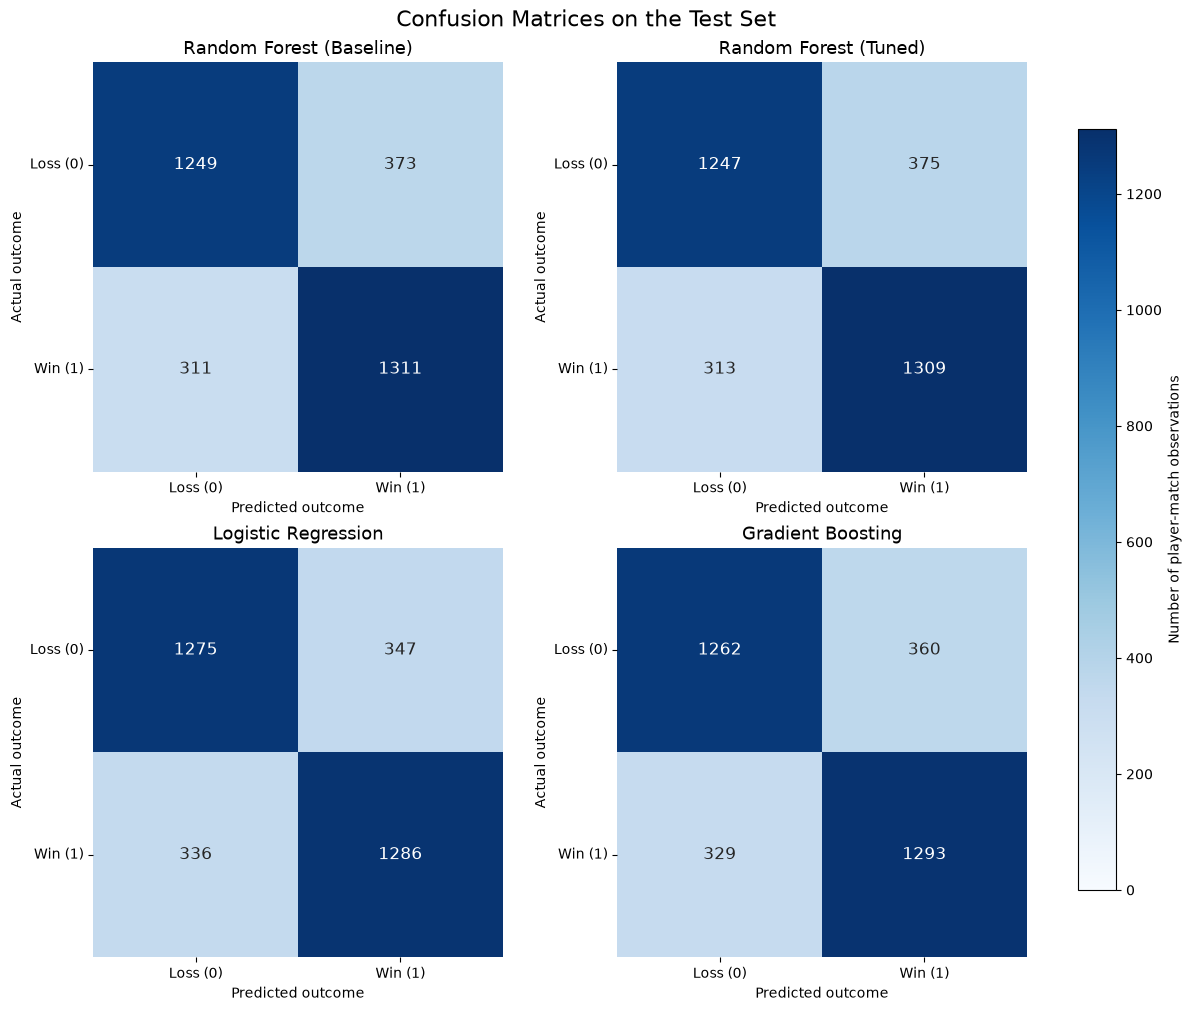

In [23]:
models_to_compare = {
    "Random Forest (Baseline)": model,
    "Random Forest (Tuned)": best_rf,
    "Logistic Regression": model_2,
    "Gradient Boosting": model_3
}

# Calculate each matrix using the same class order
confusion_matrices = {
    name: confusion_matrix(
        y_test,
        clf.predict(X_test),
        labels=[0, 1]
    )
    for name, clf in models_to_compare.items()
}

# Use the same color scale across all panels
max_count = max(cm.max() for cm in confusion_matrices.values())

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    constrained_layout=True
)

for ax, (name, cm) in zip(axes.flat, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=max_count,
        cbar=False,
        square=True,
        xticklabels=["Loss (0)", "Win (1)"],
        yticklabels=["Loss (0)", "Win (1)"],
        annot_kws={"fontsize": 12},
        ax=ax
    )

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Predicted outcome")
    ax.set_ylabel("Actual outcome")
    ax.tick_params(axis="both", labelrotation=0)

fig.colorbar(
    axes[0, 0].collections[0],
    ax=axes.ravel().tolist(),
    label="Number of player-match observations",
    shrink=0.85
)

fig.suptitle("Confusion Matrices on the Test Set", fontsize=16)
plt.show()

### Interpreting the Confusion Matrices

All four models correctly classify most player-match observations. Their total error counts are close: **683 for Logistic Regression**, **684 for the Random Forest baseline**, **688 for the tuned Random Forest**, and **689 for Gradient Boosting**.

Every model makes slightly more errors by classifying actual losses as wins than by classifying actual wins as losses. Logistic Regression has the most even distribution, with **347** errors of the first kind and **336** of the second.

Compared with the Random Forest baseline, Logistic Regression correctly identifies **26 additional losses** but **25 fewer wins**. Its net improvement is therefore just one correct classification. This illustrates how similar overall accuracy can conceal differences in class-specific performance.

The figure summarizes aggregate counts. Similar confusion matrices do not establish that the models make mistakes on the same individual observations.

### Comparing How the Models Use Their Features

All four model configurations use the same 14 input features. The following panels summarize their use of those features through two different measures:

- **Random Forest and Gradient Boosting:** normalized, impurity-based feature importances. Larger values indicate greater contributions to separating the classes during tree construction. These scores do not indicate a direction of association.

- **Logistic Regression:** coefficients for standardized features. A positive coefficient increases the model's predicted log-odds of winning as that feature increases, holding the other inputs fixed. A negative coefficient decreases them.

Tree importances and Logistic Regression coefficients have different meanings and scales. Their numerical magnitudes should not be compared directly.

Several inputs are correlated or derived from the same counts. Their rankings and coefficients depend on the other features included in the model and should be interpreted together.

These panels describe the fitted models, rather than establishing the causes of match outcomes.

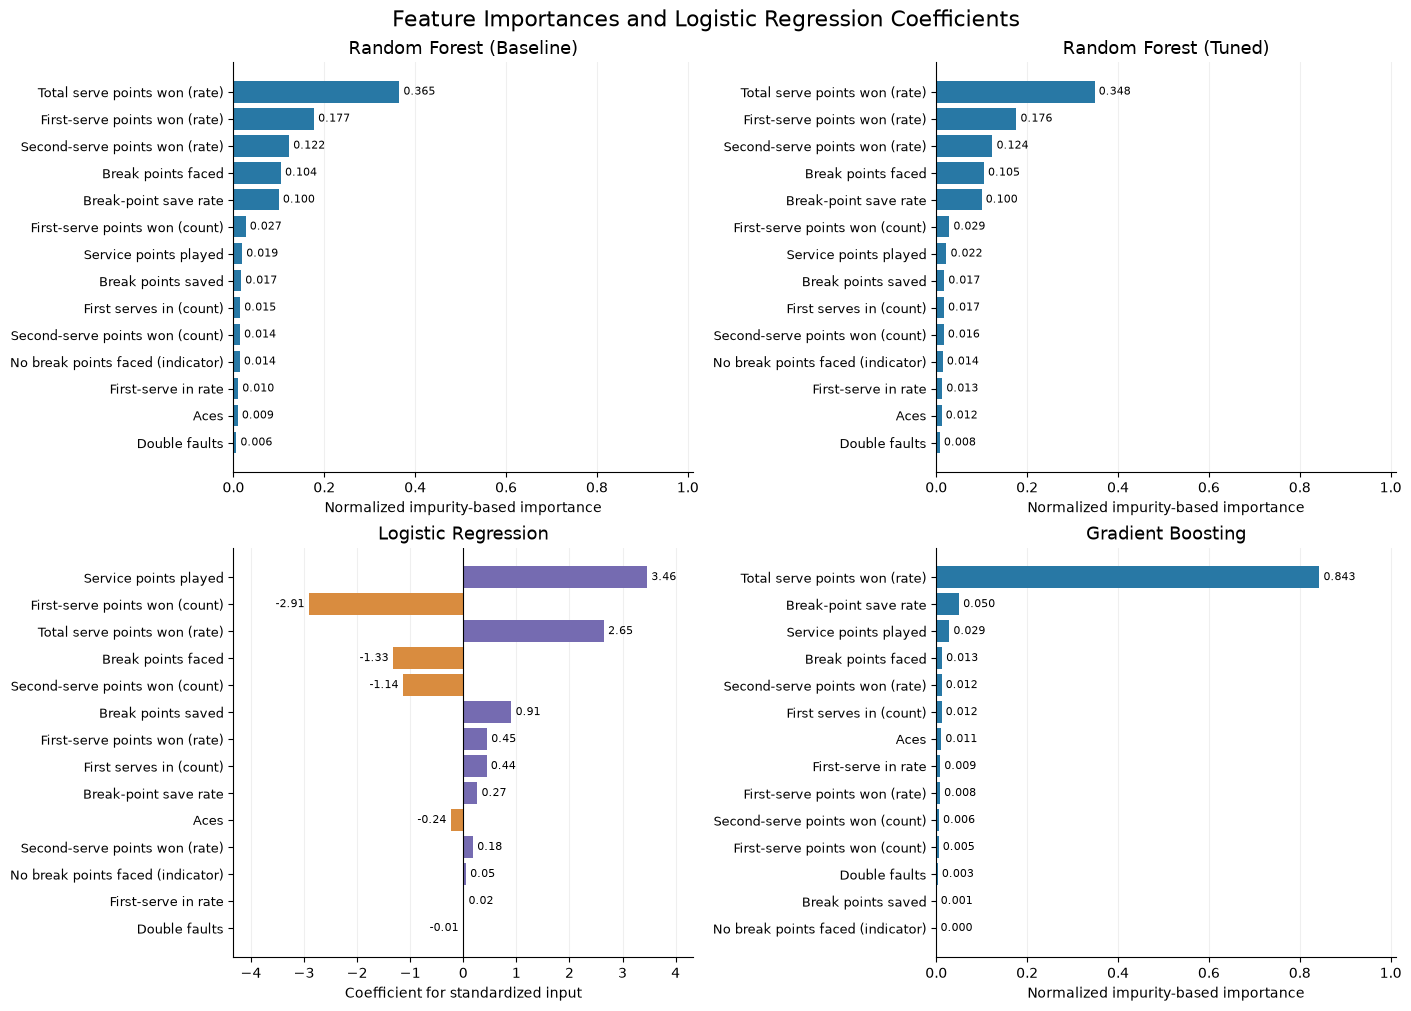

In [26]:
# Extract values using the same feature names for every model
feature_names = X_train.columns

rf_importances = pd.Series(
    model.feature_importances_, index=feature_names
)

tuned_rf_importances = pd.Series(
    best_rf.feature_importances_, index=feature_names
)

lr_coefs = pd.Series(
    model_2.named_steps["logreg"].coef_[0],
    index=feature_names
)

gb_importances = pd.Series(
    model_3.feature_importances_, index=feature_names
)

panels = [
    ("Random Forest (Baseline)", rf_importances, "importance"),
    ("Random Forest (Tuned)", tuned_rf_importances, "importance"),
    ("Logistic Regression", lr_coefs, "coefficient"),
    ("Gradient Boosting", gb_importances, "importance")
]

# Shared scale for the three tree-based panels
max_importance = max(
    rf_importances.max(),
    tuned_rf_importances.max(),
    gb_importances.max()
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    constrained_layout=True
)

for ax, (title, values, kind) in zip(axes.flat, panels):
    if kind == "coefficient":
        # Put the largest coefficient magnitudes at the top
        ordered = values.loc[values.abs().sort_values().index]
        colors = [
            "#756BB1" if value >= 0 else "#D98C3F"
            for value in ordered
        ]
    else:
        ordered = values.sort_values()
        colors = "#2878A5"

    labels = [
        feature_labels.get(feature, feature)
        for feature in ordered.index
    ]

    bars = ax.barh(labels, ordered.values, color=colors)

    if kind == "coefficient":
        ax.axvline(0, color="black", linewidth=0.8)

        limit = ordered.abs().max() * 1.25
        ax.set_xlim(-limit, limit)
        ax.set_xlabel("Coefficient for standardized input")
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    else:
        ax.set_xlim(0, max_importance * 1.2)
        ax.set_xlabel("Normalized impurity-based importance")
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.2)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    "Feature Importances and Logistic Regression Coefficients",
    fontsize=16
)
plt.show()

### Interpreting the Feature Comparison

All four configurations use the same 14 inputs, but they distribute importance or coefficient weight differently.

**Random Forest:** Both configurations show similar rankings. Total serve points won rate ranks first, with importance scores of approximately **0.365** for the baseline and **0.348** for the tuned model. First- and second-serve points won rates follow, alongside break-point statistics.

**Gradient Boosting:** Importance is concentrated heavily in total serve points won rate (**0.843**), followed by break-point save rate (**0.050**). This concentration does not represent accuracy or the percentage of matches decided by a feature. Its test accuracy remains similar to that of the other models.

**Logistic Regression:** The largest coefficient magnitudes include service points played (**+3.46**), first-serve points won count (**−2.91**), and total serve points won rate (**+2.65**).

The negative coefficient for first-serve points won count must not be interpreted as evidence that winning those points is harmful. Counts and their derived rates overlap mathematically, and the coefficients describe their joint role in the fitted model. Changing one input while holding every related input fixed may not represent a realistic tennis scenario.

For individual match examples, we will combine each coefficient with that player's standardized feature value. This explains contributions to the model's score, while the match statistics provide separate context for interpreting the actual result.

### Real Match Examples: Predictions and Explanations

We use the fitted Logistic Regression model to examine individual player observations from held-out matches. The examples include a correctly classified winner and both types of error: a loser classified as a winner and a winner classified as a loser.

For each example, we show:

- The players, actual match result, and predicted outcome.
- Serving statistics for both players and their derived return-point win rates.
- The features contributing most strongly toward a win or loss classification.

For Logistic Regression, each feature's contribution is its standardized value multiplied by its coefficient. These contributions, together with the intercept, reproduce the model's score in log-odds units. They explain the model's calculation, not the causes of the match result.

Opponent statistics and return-point win rates provide additional context; they are not inputs to the current model.

The examples are illustrative. They cannot establish how frequently particular factors cause classification errors. Serve placement, speed, and spin are not recorded, so explanations involving those factors remain hypotheses.

In [27]:
from IPython.display import Markdown, display

# Use the selected Logistic Regression pipeline
chosen_model = model_2
results_df = df.loc[X_test.index].copy()
results_df['true'] = y_test
results_df['pred'] = chosen_model.predict(X_test)
win_column = list(chosen_model.classes_).index(1)
results_df['win_probability'] = chosen_model.predict_proba(X_test)[:, win_column]

# Add match details for interpretation only
match_details = df_raw.assign(
    match_id=(df_raw['tourney_id'].astype(str) + '_' + df_raw['match_num'].astype(str))
).set_index('match_id')
detail_columns = [
    'tourney_id', 'tourney_name', 'round', 'surface',
    'score', 'winner_name', 'loser_name'
]
results_df = results_df.join(
    match_details[detail_columns], on='match_id', validate='many_to_one'
)

# Calculate exact contributions to the model's log-odds score
scaler = chosen_model.named_steps['scaler']
logreg = chosen_model.named_steps['logreg']
contributions = pd.DataFrame(
    scaler.transform(X_test) * logreg.coef_[0],
    index=X_test.index, columns=X_test.columns
)
training_means = pd.Series(scaler.mean_, index=X_test.columns)
intercept = float(logreg.intercept_[0])

np.testing.assert_allclose(
    contributions.sum(axis=1) + intercept,
    chosen_model.decision_function(X_test),
    rtol=1e-10, atol=1e-10
)

error_count = int(results_df['true'].ne(results_df['pred']).sum())
display(Markdown(
    f'**Logistic Regression test errors:** {error_count:,} of '
    f'{len(results_df):,} player observations '
    f'(**{error_count / len(results_df):.2%}**).'
))

def format_feature_value(feature, value):
    if feature.endswith('_pct'):
        return f'{value:.1%}'
    return f'{value:.2f}'.rstrip('0').rstrip('.')

def show_match_example(row, heading):
    opponent = df.loc[
        df['match_id'].eq(row['match_id']) & (df.index != row.name)
    ].iloc[0]
    season = str(row['tourney_id']).split('-')[0]
    predicted_label = 'Win' if row['pred'] == 1 else 'Loss'

    display(Markdown(
        f"### {heading}: {row['player']} vs {row['opponent']}\n\n"
        f"**{row['tourney_name']} ({season}) | {row['round']} | {row['surface']}**\n\n"
        f"**Actual result:** {row['winner_name']} beat {row['loser_name']} "
        f"{row['score']}.\n\n"
        f"**Classification for {row['player']}: {predicted_label}.** "
        f"Model win-class probability: **{row['win_probability']:.1%}**."
    ))

    rate_fields = [
        'first_serve_pct', 'first_serve_points_won_pct',
        'second_serve_points_won_pct', 'total_serve_points_won_pct'
    ]
    stats = pd.DataFrame({
        row['player']: [f'{row[f]:.1%}' for f in rate_fields] + [
            f"{1 - opponent['total_serve_points_won_pct']:.1%}",
            f"{row['bpSaved']:.0f} / {row['bpFaced']:.0f}"
        ],
        row['opponent']: [f'{opponent[f]:.1%}' for f in rate_fields] + [
            f"{1 - row['total_serve_points_won_pct']:.1%}",
            f"{opponent['bpSaved']:.0f} / {opponent['bpFaced']:.0f}"
        ]
    }, index=[feature_labels[f] for f in rate_fields] + [
        'Return points won (rate)', 'Break points saved / faced'
    ])
    display(stats)

    # Show two contributions in each direction and account for the remainder
    local = contributions.loc[row.name]
    selected = pd.concat([
        local[local > 0].nlargest(2),
        local[local < 0].nsmallest(2)
    ])
    explanation = pd.DataFrame({
        'Match value': [format_feature_value(f, row[f]) for f in selected.index],
        'Training mean': [format_feature_value(f, training_means[f]) for f in selected.index],
        'Contribution (log-odds)': selected.values
    }, index=[feature_labels[f] for f in selected.index])
    explanation.loc['Other features (combined)'] = ['—', '—', local.sum() - selected.sum()]
    explanation.loc['Model intercept'] = ['—', '—', intercept]
    explanation.loc['Total model score'] = ['—', '—', local.sum() + intercept]

    display(Markdown(
        '**Contributions to the classification:** positive values push the '
        'score toward Win; negative values push it toward Loss. '
        'The score includes all features and the intercept.'
    ))
    display(explanation.style.format({'Contribution (log-odds)': '{:+.3f}'}))

# Sample illustrative cases; the full test error above includes every test row
eligible = results_df.loc[
    results_df['score'].notna()
    & ~results_df['score'].str.contains(r'RET|W/O|DEF|ABD', case=False, na=False)
].copy()
display(Markdown(
    'Examples are sampled with **random_state = 42**, one per category. '
    'Recorded retirements, walkovers, defaults, and abandonments are excluded '
    'from these illustrations. Each selected match is shown once.'
))

example_specs = [
    ('Correctly classified win', 1, 1),
    ('Loss classified as a win', 0, 1),
    ('Win classified as a loss', 1, 0)
]
example_rows = []
for heading, actual, predicted in example_specs:
    candidates = eligible.loc[
        eligible['true'].eq(actual) & eligible['pred'].eq(predicted)
    ]
    if candidates.empty:
        display(Markdown(f'**{heading}:** no eligible example.'))
        continue
    example = candidates.sample(1, random_state=42).iloc[0]
    example_rows.append(example)
    show_match_example(example, heading)
    eligible = eligible.loc[eligible['match_id'].ne(example['match_id'])]

**Logistic Regression test errors:** 683 of 3,244 player observations (**21.05%**).

Examples are sampled with **random_state = 42**, one per category. Recorded retirements, walkovers, defaults, and abandonments are excluded from these illustrations. Each selected match is shown once.

### Correctly classified win: Kevin Anderson vs Marsel Ilhan

**Wimbledon (2015) | R64 | Grass**

**Actual result:** Kevin Anderson beat Marsel Ilhan 6-7(5) 7-6(6) 6-4 6-4.

**Classification for Kevin Anderson: Win.** Model win-class probability: **82.8%**.

,Kevin Anderson,Marsel Ilhan
First-serve in rate,58.0%,58.6%
First-serve points won (rate),85.5%,73.1%
Second-serve points won (rate),70.0%,58.2%
Total serve points won (rate),79.0%,66.9%
Return points won (rate),33.1%,21.0%
Break points saved / faced,0 / 0,1 / 3


**Contributions to the classification:** positive values push the score toward Win; negative values push it toward Loss. The score includes all features and the intercept.

,Match value,Training mean,Contribution (log-odds)
Service points played,119,80.3,+4.551
Total serve points won (rate),79.0%,63.8%,+4.355
First-serve points won (count),59,35.06,-4.904
Second-serve points won (count),35,16.06,-3.008
Other features (combined),—,—,+0.675
Model intercept,—,—,-0.100
Total model score,—,—,+1.570


### Loss classified as a win: Ivo Karlovic vs Stan Wawrinka

**Indian Wells Masters (2014) | R64 | Hard**

**Actual result:** Stan Wawrinka beat Ivo Karlovic 6-3 7-5.

**Classification for Ivo Karlovic: Win.** Model win-class probability: **83.7%**.

,Ivo Karlovic,Stan Wawrinka
First-serve in rate,69.6%,57.1%
First-serve points won (rate),81.2%,87.5%
Second-serve points won (rate),57.1%,70.8%
Total serve points won (rate),73.9%,80.4%
Return points won (rate),19.6%,26.1%
Break points saved / faced,0 / 2,0 / 0


**Contributions to the classification:** positive values push the score toward Win; negative values push it toward Loss. The score includes all features and the intercept.

,Match value,Training mean,Contribution (log-odds)
Total serve points won (rate),73.9%,63.8%,+2.899
First-serve points won (count),26,35.06,+1.856
Service points played,46,80.3,-4.034
Break points saved,0,4.07,-1.145
Other features (combined),—,—,+2.158
Model intercept,—,—,-0.100
Total model score,—,—,+1.634


### Win classified as a loss: Simone Bolelli vs Federico Delbonis

**Winston-Salem (2015) | R64 | Hard**

**Actual result:** Simone Bolelli beat Federico Delbonis 6-4 6-3.

**Classification for Simone Bolelli: Loss.** Model win-class probability: **47.0%**.

,Simone Bolelli,Federico Delbonis
First-serve in rate,57.9%,64.1%
First-serve points won (rate),75.0%,68.3%
Second-serve points won (rate),43.8%,39.1%
Total serve points won (rate),61.8%,57.8%
Return points won (rate),42.2%,38.2%
Break points saved / faced,1 / 2,7 / 10


**Contributions to the classification:** positive values push the score toward Win; negative values push it toward Loss. The score includes all features and the intercept.

,Match value,Training mean,Contribution (log-odds)
Break points faced,2,6.7,+1.401
First-serve points won (count),33,35.06,+0.422
Break points saved,1,4.07,-0.863
Total serve points won (rate),61.8%,63.8%,-0.563
Other features (combined),—,—,-0.417
Model intercept,—,—,-0.100
Total model score,—,—,-0.121


### Interpreting the Match Examples

#### Correct classification: Kevin Anderson versus Marsel Ilhan

Anderson defeated Ilhan at Wimbledon in 2015. The model correctly classified Anderson as a winner, assigning an **82.8% win-class probability**.

Anderson won **85.5% of first-serve points**, compared with Ilhan’s **73.1%**, and **70.0% of second-serve points**, compared with **58.2%**. His overall service-point win rate was **79.0% versus 66.9%**.

Service points played and total serve points won rate supplied the largest positive model contributions: **+4.551** and **+4.355 log-odds**, respectively. After accounting for the remaining features and intercept, the combined score favored a win classification.

The serving statistics provide a concrete performance advantage consistent with the actual result. The feature contributions explain how the model arrived at its classification.

#### Incorrect win classification: Ivo Karlovic versus Stan Wawrinka

The model assigned Karlovic an **83.7% win-class probability**, but Wawrinka defeated him 6–3, 7–5 at Indian Wells in 2014.

Karlovic won **81.2% of first-serve points** and **73.9% of service points overall**. His overall service-point win rate contributed **+2.899 log-odds** toward a win classification.

However, Wawrinka won an even greater share of his own service points: **80.4%**. Karlovic won only **19.6% of return points**, compared with Wawrinka’s **26.1%**.

This illustrates how strong serving figures can coexist with a loss. Wawrinka’s own serving statistics and Karlovic’s return-point win rate were not inputs to Karlovic’s classification, so the model lacked this direct comparison between opponents.

#### Incorrect loss classification: Simone Bolelli versus Federico Delbonis

The model assigned Bolelli a **47.0% win-class probability**, producing a loss classification. Bolelli nevertheless defeated Delbonis 6–4, 6–3 at Winston-Salem in 2015.

Bolelli won **61.8% of his service points**, below the training average of **63.8%**. This feature contributed **−0.563 log-odds**, and the combined model score fell slightly below the win threshold.

Yet Delbonis won just **57.8% of his own service points**. Bolelli also had the higher return-point win rate: **42.2% versus 38.2%**.

The example shows why a player’s performance relative to the opponent matters, even when their own serving figures appear modest against the training average.

#### What the errors establish

Logistic Regression misclassified **683 of 3,244 player-match observations: 21.05%**.

This is a classification error rate, not the percentage of matches lost because of poor serve placement or another specific factor. The examples demonstrate missing opponent context, but do not establish the causes of all errors.

Serve placement, speed, and spin could provide additional context, but the dataset does not measure them. Attributing these results to those factors would require further evidence.

## Conclusion

This project compared four model configurations for classifying tennis
match outcomes using statistics recorded during completed ATP matches
from 2014–2016.

After preprocessing, the dataset contained 8,107 matches and 16,214
player-match observations. Both players from each match were kept
together during the training/test split and Random Forest cross-validation,
preventing the same match from appearing on both sides.

On the held-out test set, accuracy ranged from 78.76% to 78.95%.
Logistic Regression achieved the highest observed accuracy, although the
difference between the strongest and weakest results was only six
player-match observations. These results do not establish a meaningful
performance advantage for any model.

Logistic Regression was used for the individual examples because it
combined competitive performance with an inspectable decision function.
The tree-based models consistently assigned the greatest importance to
the total serve points won rate.

The named match examples connect these findings to tennis performance:
strong serving statistics can accompany either a win or a loss, while
the opponent's performance and derived return statistics provide useful
context. These comparisons describe recorded matches; they do not
establish what caused a result.

## Limitations

- **Retrospective analysis:** The features come from the match being
  classified and are unavailable before it begins. The reported accuracy
  therefore does not measure the ability to forecast future matches.

- **Evaluation unit:** Accuracy measures individual player-match
  observations. Each match contributes two related observations.
  Independently calculated player scores can produce inconsistent
  predictions for a pair and should not be treated as complementary
  head-to-head probabilities.

- **Validation scope:** Evaluation used one grouped random test split.
  Players can appear in both training and test data, and the split does
  not reproduce forecasting a later season. Small differences between
  models should be interpreted cautiously.

- **Interpretability:** Several counts and rates contain overlapping
  information. Feature importances and Logistic Regression contributions
  describe model behavior, not causal effects or independent coaching
  recommendations.

- **Data coverage:** The analysis covers three ATP seasons and excludes
  678 matches with missing or invalid statistics. These exclusions may
  affect representativeness. Match-completion status was not used as a
  general exclusion rule.

- **Unobserved context:** The models do not directly include return
  performance, serve placement, speed, spin, or point-by-point context.
  The Logistic Regression error rate of 21.05% does not establish that
  any particular missing factor explains those errors.

## Future Work

1. **Create a historical matchup explorer.** Develop a separate add-on
   where users select players and an available held-out match, compare
   model scores and performance statistics, and inspect the actual
   result. Clearly distinguish historical analysis from forecasting.

2. **Include opponent and return information.** Evaluate whether
   opponent-relative statistics and derived return rates improve
   retrospective classification.

3. **Develop a pre-match forecasting version.** Construct features using
   only information available before each match, such as lagged serving
   and return statistics, recent form, and surface-specific performance.
   Evaluate this version chronologically on later matches.

4. **Strengthen reliability checks.** Expand the seasons covered, define
   a consistent policy for incomplete matches, assess performance across
   additional grouped or chronological splits, and evaluate probability
   calibration before presenting scores as reliable probabilities.


<p align="center"><strong>Project by Alex Balica</strong><br>
Professional Tennis Coach, Boca Bridges Racquet Club</p>